In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("C:\\Users\\gigan\\Downloads\\imdb_top_1000.csv")
df.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [5]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB
None
Poster_Link        0
Series_Titl

In [6]:
df['Meta_score'].fillna(df['Meta_score'].median(), inplace=True)
df.dropna(subset=['IMDB_Rating', 'Genre'], inplace=True)

In [7]:
df['Genre'] = df['Genre'].str.strip()

In [8]:
print("Summary Statistics of IMDB Ratings:")
print(df['IMDB_Rating'].describe())

print(f"\nMean Rating: {df['IMDB_Rating'].mean():.2f}")
print(f"Median Rating: {df['IMDB_Rating'].median():.2f}")
print(f"Mode Rating: {df['IMDB_Rating'].mode()[0]:.2f}")

Summary Statistics of IMDB Ratings:
count    1000.000000
mean        7.949300
std         0.275491
min         7.600000
25%         7.700000
50%         7.900000
75%         8.100000
max         9.300000
Name: IMDB_Rating, dtype: float64

Mean Rating: 7.95
Median Rating: 7.90
Mode Rating: 7.70


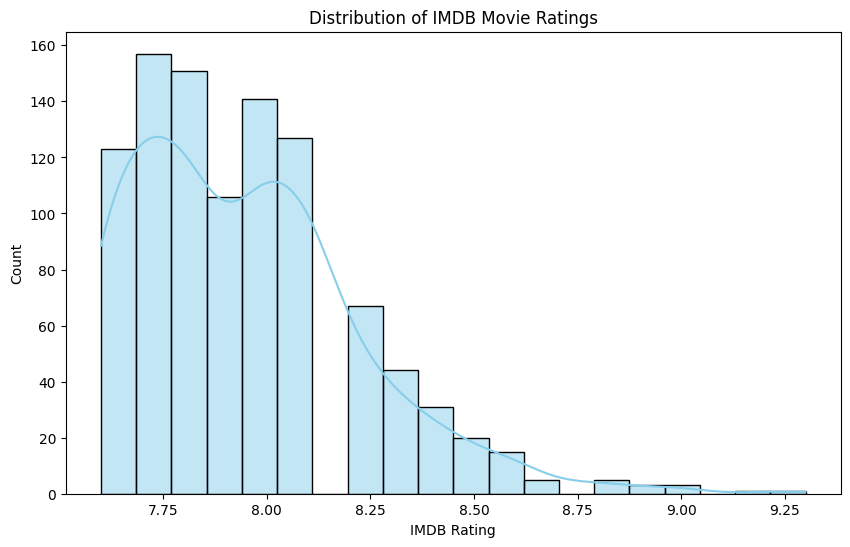

In [9]:
plt.figure(figsize=(10,6))
sns.histplot(df['IMDB_Rating'], kde=True, bins=20, color='skyblue')
plt.title('Distribution of IMDB Movie Ratings')
plt.xlabel('IMDB Rating')
plt.ylabel('Count')
plt.show()

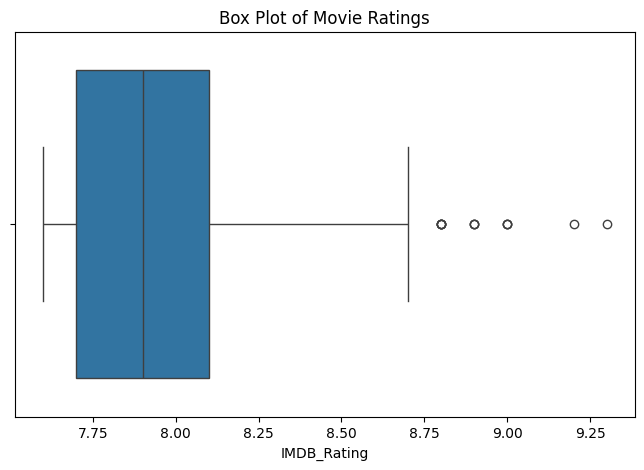

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['IMDB_Rating'])
plt.title('Box Plot of Movie Ratings')
plt.show()

In [11]:
top_movies = df.nlargest(10, 'IMDB_Rating')[['Series_Title', 'IMDB_Rating', 'Genre', 'Released_Year']]
print(top_movies)

                                    Series_Title  IMDB_Rating  \
0                       The Shawshank Redemption          9.3   
1                                  The Godfather          9.2   
2                                The Dark Knight          9.0   
3                         The Godfather: Part II          9.0   
4                                   12 Angry Men          9.0   
5  The Lord of the Rings: The Return of the King          8.9   
6                                   Pulp Fiction          8.9   
7                               Schindler's List          8.9   
8                                      Inception          8.8   
9                                     Fight Club          8.8   

                       Genre Released_Year  
0                      Drama          1994  
1               Crime, Drama          1972  
2       Action, Crime, Drama          2008  
3               Crime, Drama          1974  
4               Crime, Drama          1957  
5   Action, Ad

In [12]:
df['Main_Genre'] = df['Genre'].str.split(',').str[0]
genre_ratings = df.groupby('Main_Genre')['IMDB_Rating'].mean().sort_values(ascending=False)
print(genre_ratings.head(10))

Main_Genre
Western      8.350000
Crime        8.016822
Fantasy      8.000000
Mystery      7.975000
Film-Noir    7.966667
Drama        7.957439
Action       7.949419
Biography    7.938636
Adventure    7.937500
Animation    7.930488
Name: IMDB_Rating, dtype: float64
